# Video Game Sales Info — Exploratory Data Analysis

**dataset:** [Video Game Sales](https://www.kaggle.com/datasets/gregorut/videogamesales), sourced via kaggle — 16598 games' sales in North America, Europe, Japan markets sorted by their global sales.

**Libraries used:** `pandas`, `numpy`, `matplotlib`, `seaborn`

### Project Objective
The objective of this exploratory data analysis is to examine sales data for games by platform, genre, and publisher, in order to see how they sell in different markets and understand each market's interests.
This EDA will help identify how a publisher can target the right market and genre to become more successful.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("vgsales.csv")
print(f"DataFrame Shape(Rows, Columns): {df.shape}")
df.head()

DataFrame Shape(Rows, Columns): (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [4]:
df.nunique()

Rank            16598
Name            11493
Platform           31
Year               39
Genre              12
Publisher         578
NA_Sales          409
EU_Sales          305
JP_Sales          244
Other_Sales       157
Global_Sales      623
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

### Note on Year
Although the `Year` column initially seems useful for understanding regional taste over 
time, it is actually unreliable for that purpose. `Year` records a game's *release* 
year, while the sales figures represent *cumulative lifetime sales* recorded at the time 
this dataset was compiled — not sales that occurred during that specific year.

This creates a misleading picture. For example, imagine a game like God of War released 
in 2005, which then gets rediscovered and heavily replayed in 2020 due to a remaster or 
renewed interest. Every one of those 2020 purchases still gets attributed to 2005 in this 
dataset, since the dataset has no way to track *when* a sale actually happened — only when 
the game was first released. If we then compared this to a game like FIFA 2020, the data 
would suggest that 2005 was a big year for Action/Adventure games and 2020 was a big year 
for Sports games — when in reality, people may have been playing and buying the old God 
of War title throughout 2020, not the newer release.

Because of this, any year-over-year analysis using this column would really be measuring 
"how much a release-year cohort of games has sold by today," not "what was popular in a 
given year" or "how taste has shifted over time." Since this directly contradicts the goal 
of this Exploratory Data Analysis, I've chosen to exclude time-based 
analysis from this project rather than present a chart that could be misread as showing 
real year-by-year trends.

In [7]:
df["Publisher"] = df["Publisher"].fillna("Unknown")
df.drop(columns=["Year"], inplace=True)

In [8]:
df.describe()

,Rank,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [9]:
# Verify regional sum matches global sales
df['Regional_Sum'] = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum(axis=1)
max_diff = (df['Global_Sales'] - df['Regional_Sum']).abs().max()
print(f"Max difference between Global_Sales and Regional Sum: {max_diff:.4f}")

Max difference between Global_Sales and Regional Sum: 0.0200


## Research Objectives

#### -Publishers
Identify the top publishers in the industry based on sales figures, both globally and by region. Also examine how publisher popularity varies across regions.

#### -Genres
Identify the most popular game genres, on global market and for each region.

#### -Platforms
Identify the top-performing platforms overall, and how their performance varies by region.

#### -Games
Identify the most popular games globally and for each region, in order to understand each region's taste.

#### -Regions
Identify whether different regions follow similar patterns of taste in games.


## Market Share

Before breaking down publishers, genres, and platforms individually, it's useful to first 
establish a baseline: how big is each region's share of the overall market? Since NA_Sales, 
EU_Sales, JP_Sales, and Other_Sales are absolute values, comparing them as a percentage of 
Global_Sales gives a clearer picture of each region's relative weight. This baseline will 
also help contextualize later findings — for example, if North America dominates a specific 
genre or publisher's sales, it's worth knowing whether that's because NA genuinely prefers 
it, or simply because NA is the largest market overall.

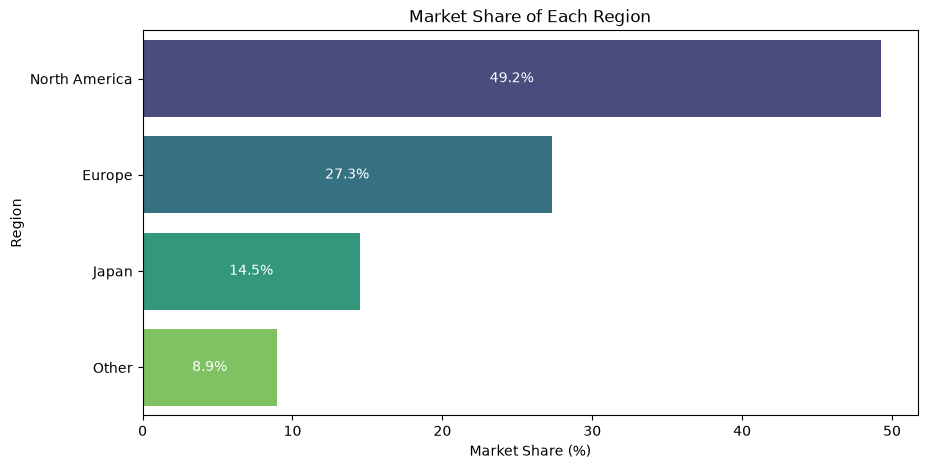

In [10]:
market_share = pd.DataFrame({"Region":["North America", "Europe", "Japan", "Other"],
                             "Market Share":[df["NA_Sales"].sum() / df["Global_Sales"].sum() * 100,
                                             df["EU_Sales"].sum()/df["Global_Sales"].sum() * 100,
                                             df["JP_Sales"].sum()/df["Global_Sales"].sum() * 100,
                                             df["Other_Sales"].sum()/df["Global_Sales"].sum() * 100
                                            ]})

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=market_share, x="Market Share", y="Region",palette="viridis", hue="Region", ax=ax)
ax.set_title("Market Share of Each Region")
ax.set_xlabel("Market Share (%)")
ax.set_ylabel("Region")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", color="white")

### Observation
North America holds nearly half of the global market share (49.2%), meaning roughly one 
in every two game purchases happens there. This gives North American tastes in genres, 
platforms, and publishers significant weight in shaping overall global sales trends. 
Europe follows with 27.3% and Japan with 14.5%, while the rest of the world accounts for 
just 8.9% of total sales.

## Publishers

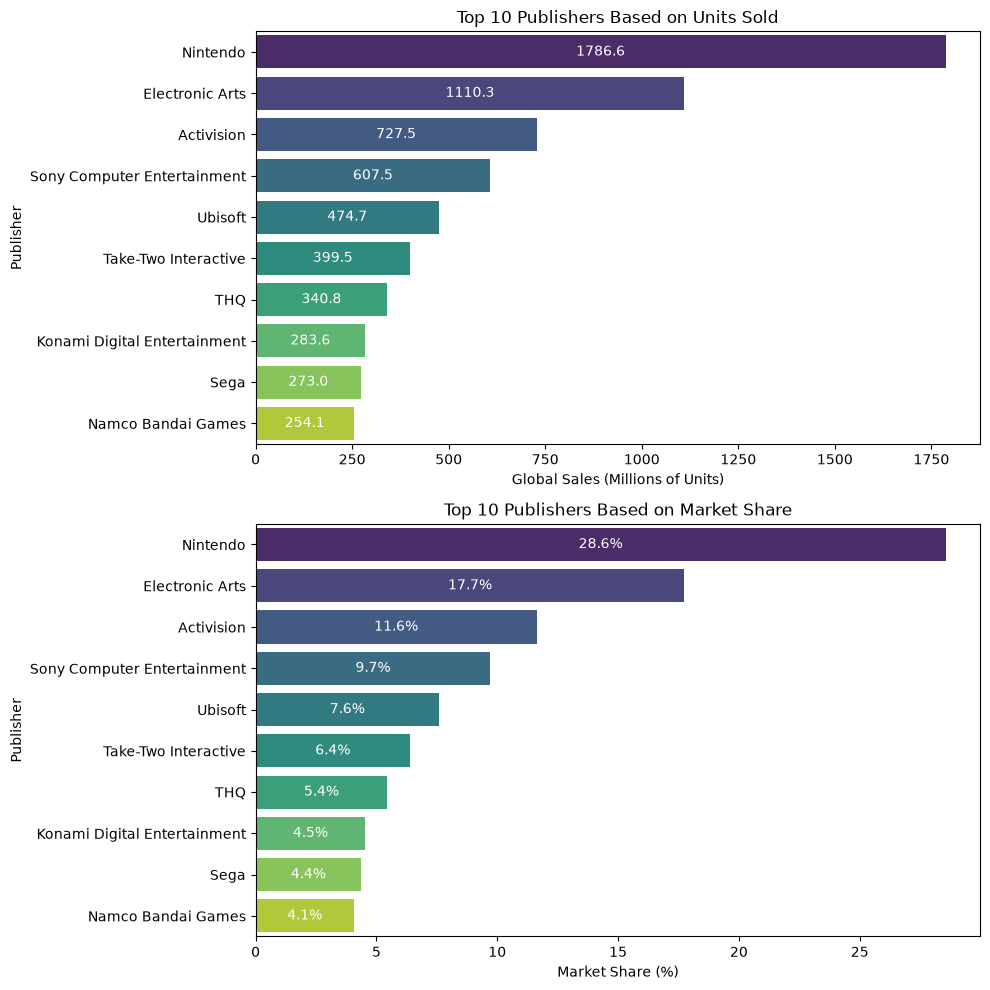

In [11]:
top_publishers = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False)[:10].reset_index()
top_publishers["Market_Share"] =  top_publishers["Global_Sales"] / top_publishers["Global_Sales"].sum() * 100

fig, ax = plt.subplots(figsize=(10,10), nrows=2, ncols=1)
sns.barplot(data=top_publishers, x="Global_Sales", y="Publisher", palette="viridis", hue="Publisher", ax=ax[0])
ax[0].set_title("Top 10 Publishers Based on Units Sold")
ax[0].set_xlabel("Global Sales (Millions of Units)")
ax[0].set_ylabel("Publisher")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=top_publishers, x="Market_Share", y="Publisher", palette="viridis", hue="Publisher", ax=ax[1])
ax[1].set_title("Top 10 Publishers Based on Market Share")
ax[1].set_xlabel("Market Share (%)")
ax[1].set_ylabel("Publisher")
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%", label_type="center", color="white")


plt.tight_layout()
plt.show()

### Observation
Nintendo, EA, and Activision are the industry's dominant publishers, together responsible 
for over 3.4 billion units sold. Nintendo alone leads with a 28.6% market share — meaning 
roughly one in every three or four games sold globally is published by Nintendo. Combined, 
these three publishers account for 57.9% of total unit sales, leaving less than half of the 
market to the remaining hundreds of publishers in the dataset.

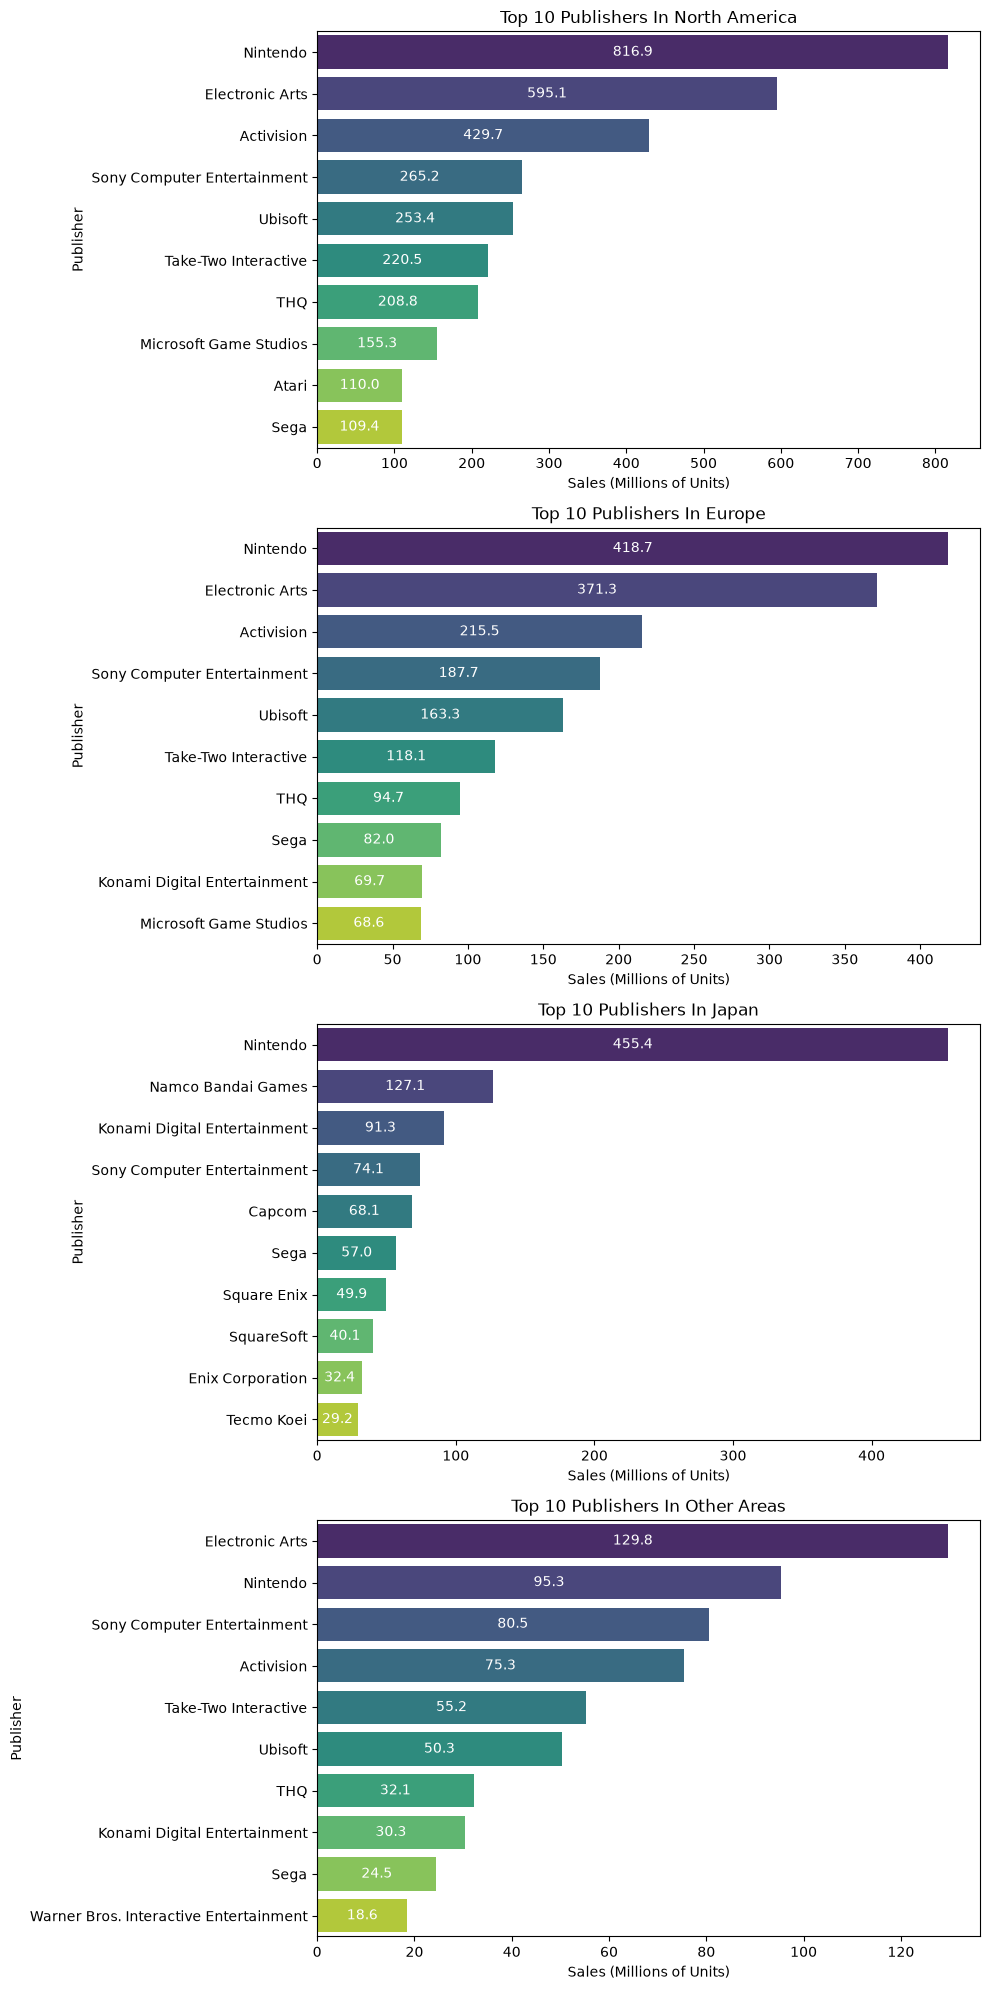

In [12]:
na = df.groupby("Publisher")["NA_Sales"].sum().sort_values(ascending=False).reset_index()[:10]
jp = df.groupby("Publisher")["JP_Sales"].sum().sort_values(ascending=False).reset_index()[:10]
eu = df.groupby("Publisher")["EU_Sales"].sum().sort_values(ascending=False).reset_index()[:10]
other = df.groupby("Publisher")["Other_Sales"].sum().sort_values(ascending=False).reset_index()[:10]

fig, ax = plt.subplots(figsize=(10,20), nrows=4, ncols=1)
sns.barplot(data=na, x="NA_Sales", y="Publisher", palette="viridis", hue="Publisher", ax=ax[0])
ax[0].set_title("Top 10 Publishers In North America")
ax[0].set_xlabel("Sales (Millions of Units)")
ax[0].set_ylabel("Publisher")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=eu, x="EU_Sales", y="Publisher", palette="viridis", hue="Publisher", ax=ax[1])
ax[1].set_title("Top 10 Publishers In Europe")
ax[1].set_xlabel("Sales (Millions of Units)")
ax[1].set_ylabel("Publisher")
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=jp, x="JP_Sales", y="Publisher", palette="viridis", hue="Publisher", ax=ax[2])
ax[2].set_title("Top 10 Publishers In Japan")
ax[2].set_xlabel("Sales (Millions of Units)")
ax[2].set_ylabel("Publisher")
for container in ax[2].containers:
    ax[2].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=other, x="Other_Sales", y="Publisher", palette="viridis", hue="Publisher", ax=ax[3])
ax[3].set_title("Top 10 Publishers In Other Areas")
ax[3].set_xlabel("Sales (Millions of Units)")
ax[3].set_ylabel("Publisher")
for container in ax[3].containers:
    ax[3].bar_label(container, fmt="%.1f", label_type="center", color="white")

plt.tight_layout()
plt.show()

### Observation
North America and Europe show very similar publisher preferences: Nintendo (a Japanese 
company) leads both markets, followed by EA and Activision, both American publishers. 
Japan, however, tells a very different story — Nintendo dominates by a wide margin, 
followed by Namco Bandai, Konami, Sony, and Capcom, all Japanese publishers. This suggests 
the Japanese market is largely resistant to non-domestic publishers, making it a difficult 
market for Western companies to break into.

Surprisingly, "Other" regions don't follow the NA/EU pattern either — EA, not Nintendo, is 
the top publisher there. This may be connected to soccer's popularity across much of the 
world, given that FIFA is one of EA's flagship titles — something worth exploring further 
in later sections.

## Genres

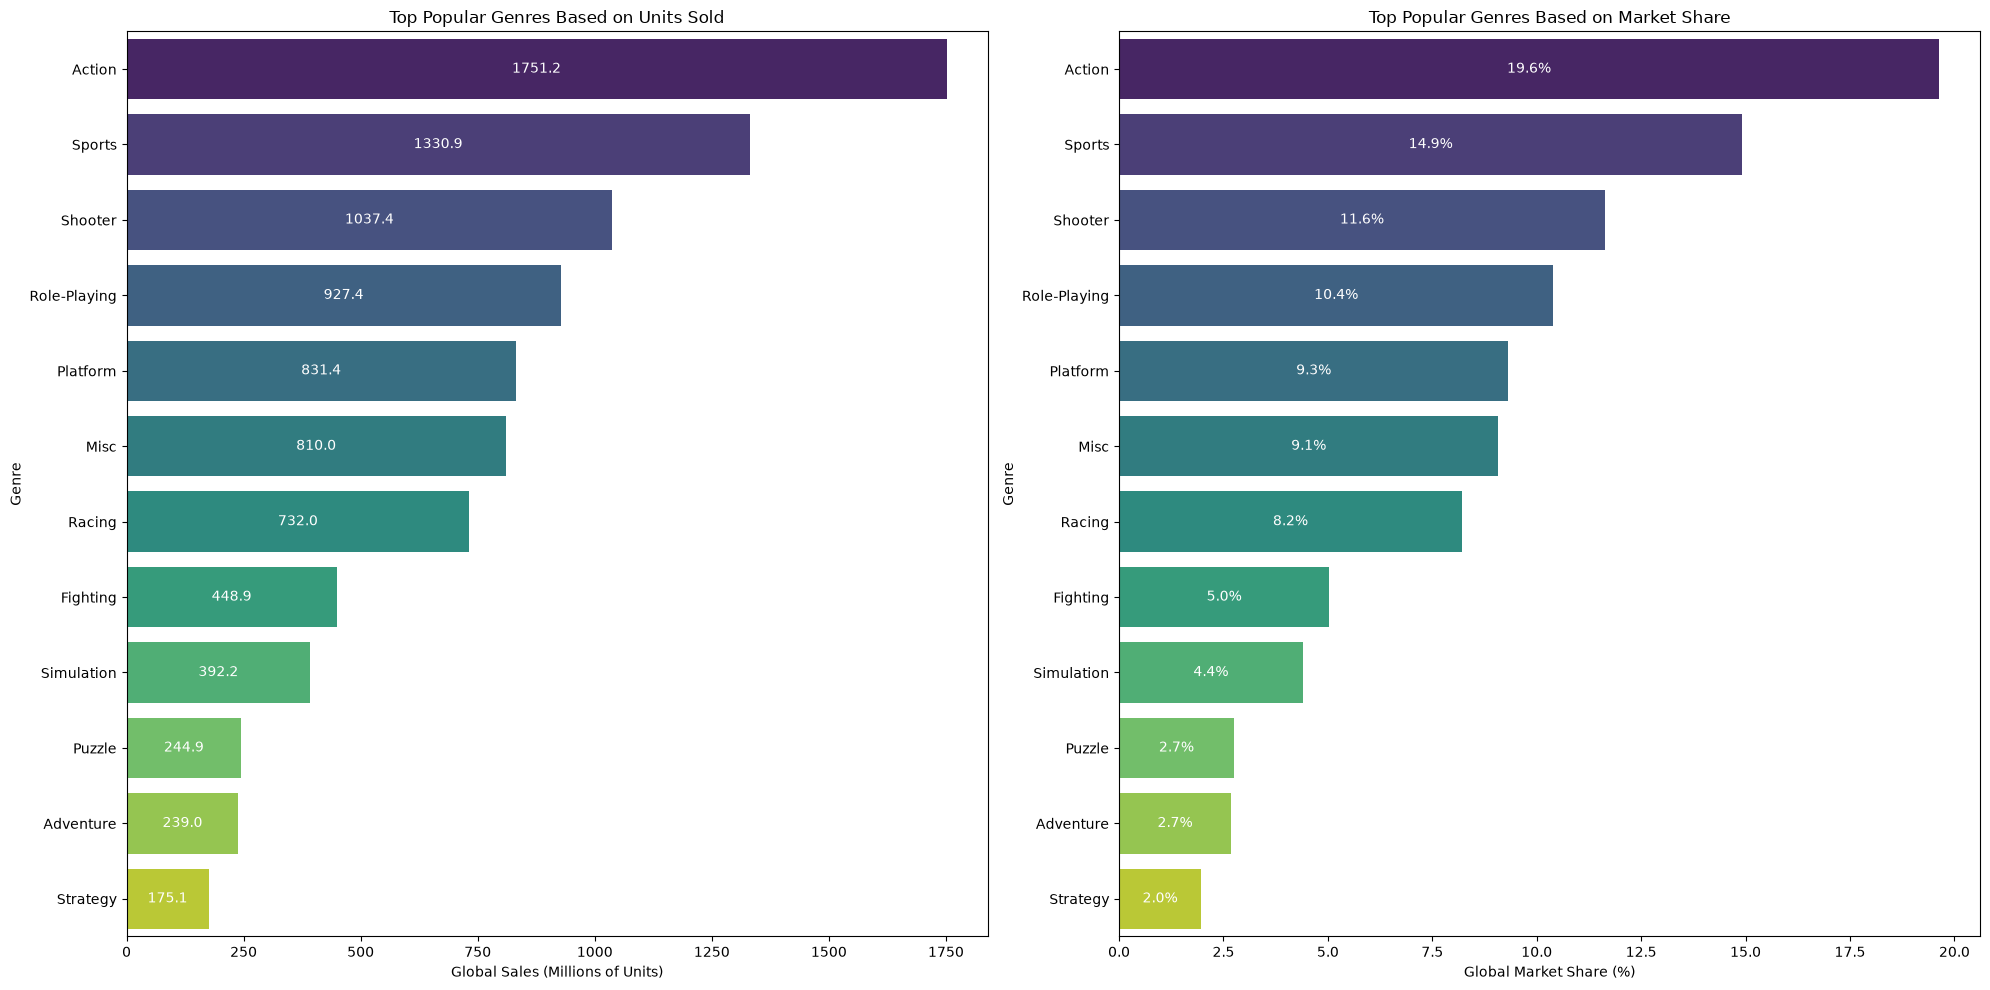

In [13]:
top_genres = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).reset_index()
top_genres["Market_Share"] = top_genres["Global_Sales"] / top_genres["Global_Sales"].sum() * 100

fig, ax = plt.subplots(figsize=(20,10), nrows=1, ncols=2)
sns.barplot(data=top_genres, x="Global_Sales", y="Genre", palette="viridis", hue="Genre", ax=ax[0])
ax[0].set_title("Top Popular Genres Based on Units Sold")
ax[0].set_xlabel("Global Sales (Millions of Units)")
ax[0].set_ylabel("Genre")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=top_genres, x="Market_Share", y="Genre", palette="viridis", hue="Genre", ax=ax[1])
ax[1].set_title("Top Popular Genres Based on Market Share")
ax[1].set_xlabel("Global Market Share (%)")
ax[1].set_ylabel("Genre")
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%", label_type="center", color="white")

plt.tight_layout()
plt.show()

### Observation
Action, Sports, and Shooter are the most popular genres in the market. Action leads by a 
meaningful margin, taking roughly 20% of total sales on its own. Together, the top 3 genres 
account for roughly 46% of the market. Role-Playing, Platform, and Misc form the next tier, 
sitting closely together in market share (10.4%, 9.3%, and 9.1% respectively) with only a 
small gap between them.

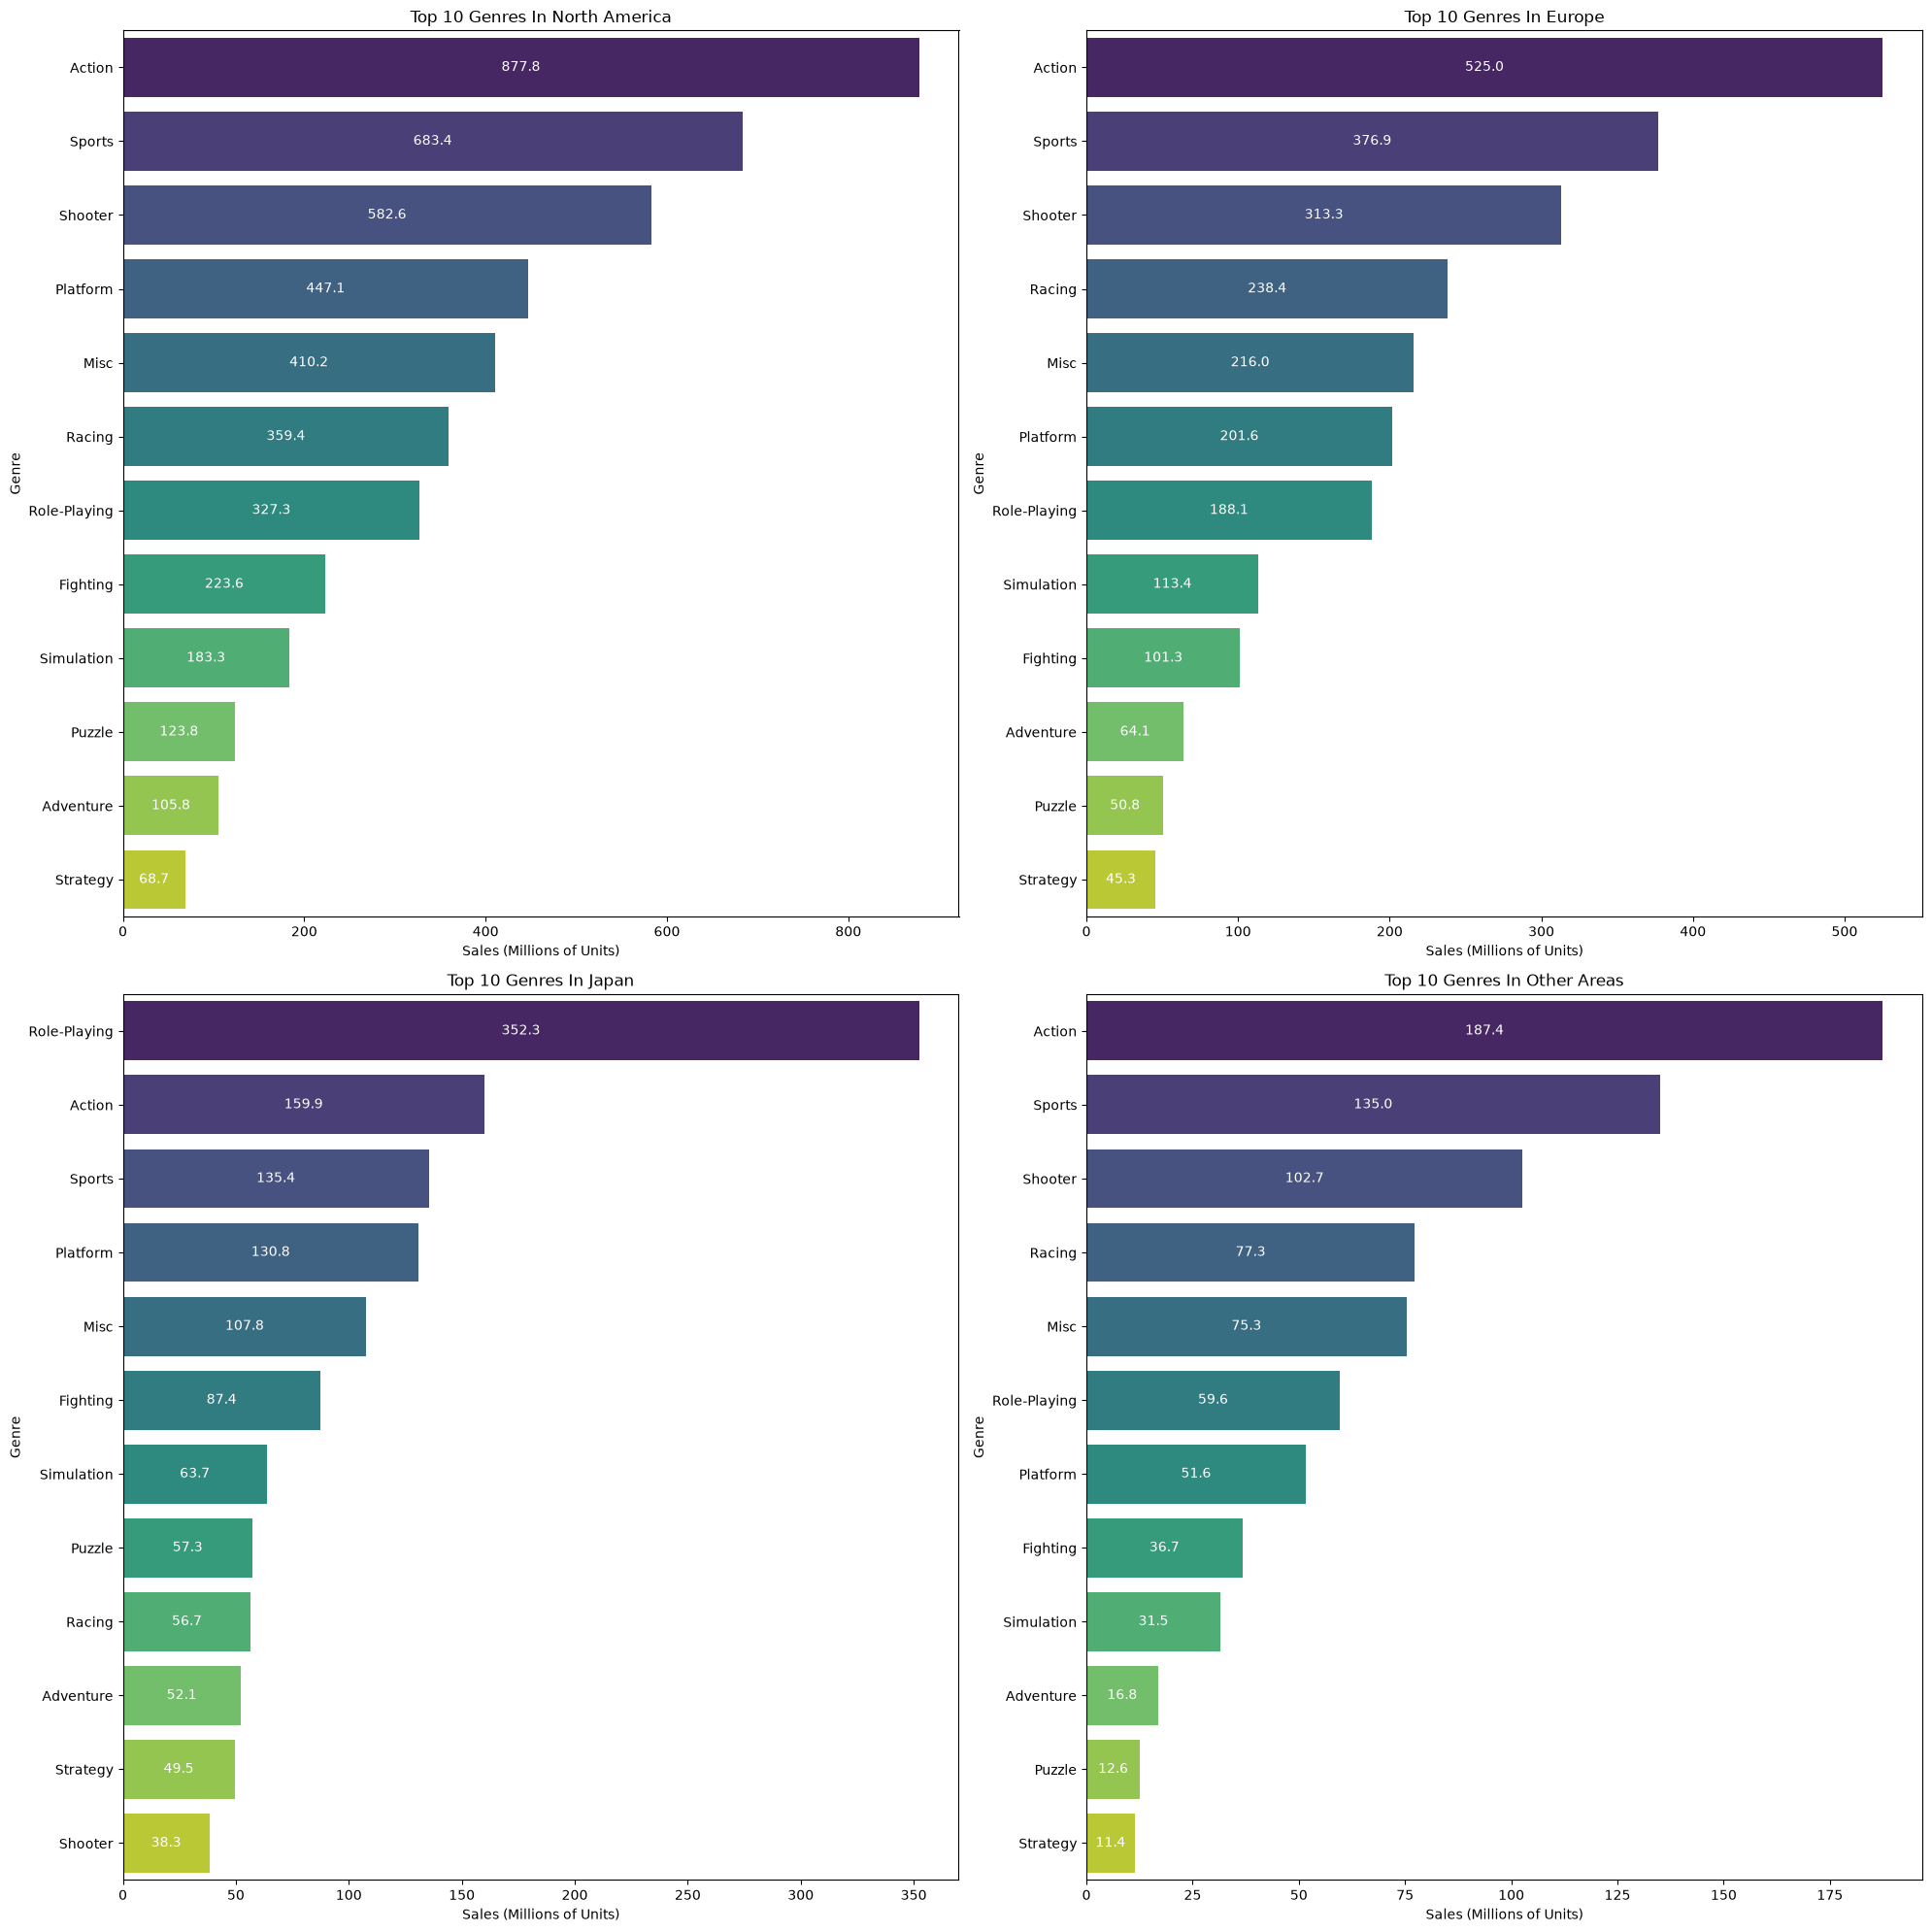

In [14]:
na1 = df.groupby("Genre")["NA_Sales"].sum().sort_values(ascending=False).reset_index()
eu1 = df.groupby("Genre")["EU_Sales"].sum().sort_values(ascending=False).reset_index()
jp1 = df.groupby("Genre")["JP_Sales"].sum().sort_values(ascending=False).reset_index()
other1 = df.groupby("Genre")["Other_Sales"].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(20,20), nrows=2, ncols=2)
sns.barplot(data=na1, x="NA_Sales", y="Genre", palette="viridis", hue="Genre", ax=ax[0,0])
ax[0,0].set_title("Top 10 Genres In North America")
ax[0,0].set_xlabel("Sales (Millions of Units)")
ax[0,0].set_ylabel("Genre")
for container in ax[0,0].containers:
    ax[0,0].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=eu1, x="EU_Sales", y="Genre", palette="viridis", hue="Genre", ax=ax[0,1])
ax[0,1].set_title("Top 10 Genres In Europe")
ax[0,1].set_xlabel("Sales (Millions of Units)")
ax[0,1].set_ylabel("Genre")
for container in ax[0,1].containers:
    ax[0,1].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=jp1, x="JP_Sales", y="Genre", palette="viridis", hue="Genre", ax=ax[1,0])
ax[1,0].set_title("Top 10 Genres In Japan")
ax[1,0].set_xlabel("Sales (Millions of Units)")
ax[1,0].set_ylabel("Genre")
for container in ax[1,0].containers:
    ax[1,0].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=other1, x="Other_Sales", y="Genre", palette="viridis", hue="Genre", ax=ax[1,1])
ax[1,1].set_title("Top 10 Genres In Other Areas")
ax[1,1].set_xlabel("Sales (Millions of Units)")
ax[1,1].set_ylabel("Genre")
for container in ax[1,1].containers:
    ax[1,1].bar_label(container, fmt="%.1f", label_type="center", color="white")

plt.tight_layout()
plt.show()

### Observation
As we saw with Market Share, North America and Europe together make up roughly 75% of the 
market, so it's no surprise that Action, Sports, and Shooter dominate genre sales in these 
two regions, mirroring the global chart. There is one notable difference, though: 
Role-Playing ranks 4th globally, but only 7th in NA and EU individually. Japan explains 
this gap — Role-Playing is by far Japan's most popular genre, and this alone is enough to 
pull it up to 4th place in the global ranking.

The "Other" regions show no meaningful deviation from the NA/EU pattern.

This also helps explain an earlier finding: since Konami and Namco Bandai are both known 
for strong Role-Playing titles, and Role-Playing is Japan's dominant genre, it makes sense 
that these two publishers ranked among the top 3 in Japan specifically.

## Platforms

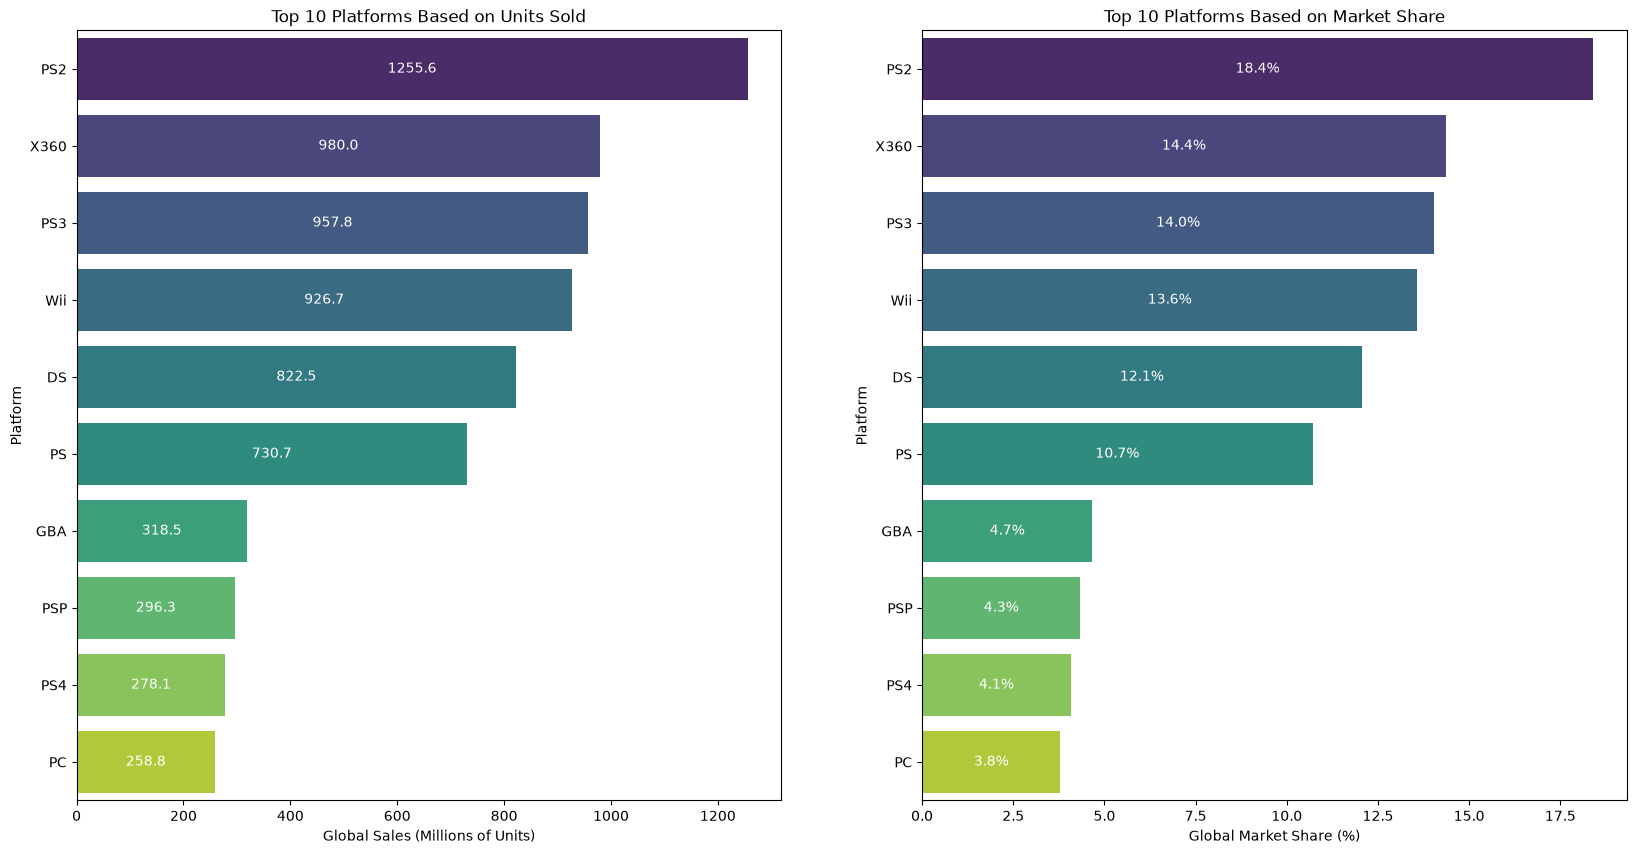

In [15]:
top_platforms = df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).reset_index()[:10]
top_platforms["Market_Share"] = top_platforms["Global_Sales"] / top_platforms["Global_Sales"].sum() * 100

fig, ax = plt.subplots(figsize=(20,10), nrows=1, ncols=2)

sns.barplot(data=top_platforms, x="Global_Sales", y="Platform", palette="viridis", hue="Platform", ax=ax[0])
ax[0].set_title("Top 10 Platforms Based on Units Sold")
ax[0].set_xlabel("Global Sales (Millions of Units)")
ax[0].set_ylabel("Platform")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f", label_type="center", color="white")


sns.barplot(data=top_platforms, x="Market_Share", y="Platform", palette="viridis", hue="Platform", ax=ax[1])
ax[1].set_title("Top 10 Platforms Based on Market Share")
ax[1].set_xlabel("Global Market Share (%)")
ax[1].set_ylabel("Platform")
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%", label_type="center", color="white")



### Observation
PlayStation 2 alone accounts for 14.1% of total global unit sales, making it the single 
best-selling platform in the dataset by a wide margin — followed by Xbox 360, PlayStation 
3, and Nintendo's Wii. Interestingly, even though Nintendo is the top publisher globally 
and Sony ranks only 4th, three of the top 6 platforms (PS2, PS3, PS) belong to Sony, with 
Wii and DS belonging to Nintendo, and only Xbox 360 representing Microsoft. This suggests 
that Sony's strength lies primarily in console hardware sales rather than in publishing 
top-selling games itself — a distinction this dataset can only measure at the platform 
level, not at the level of exclusive titles or first-party strategy.

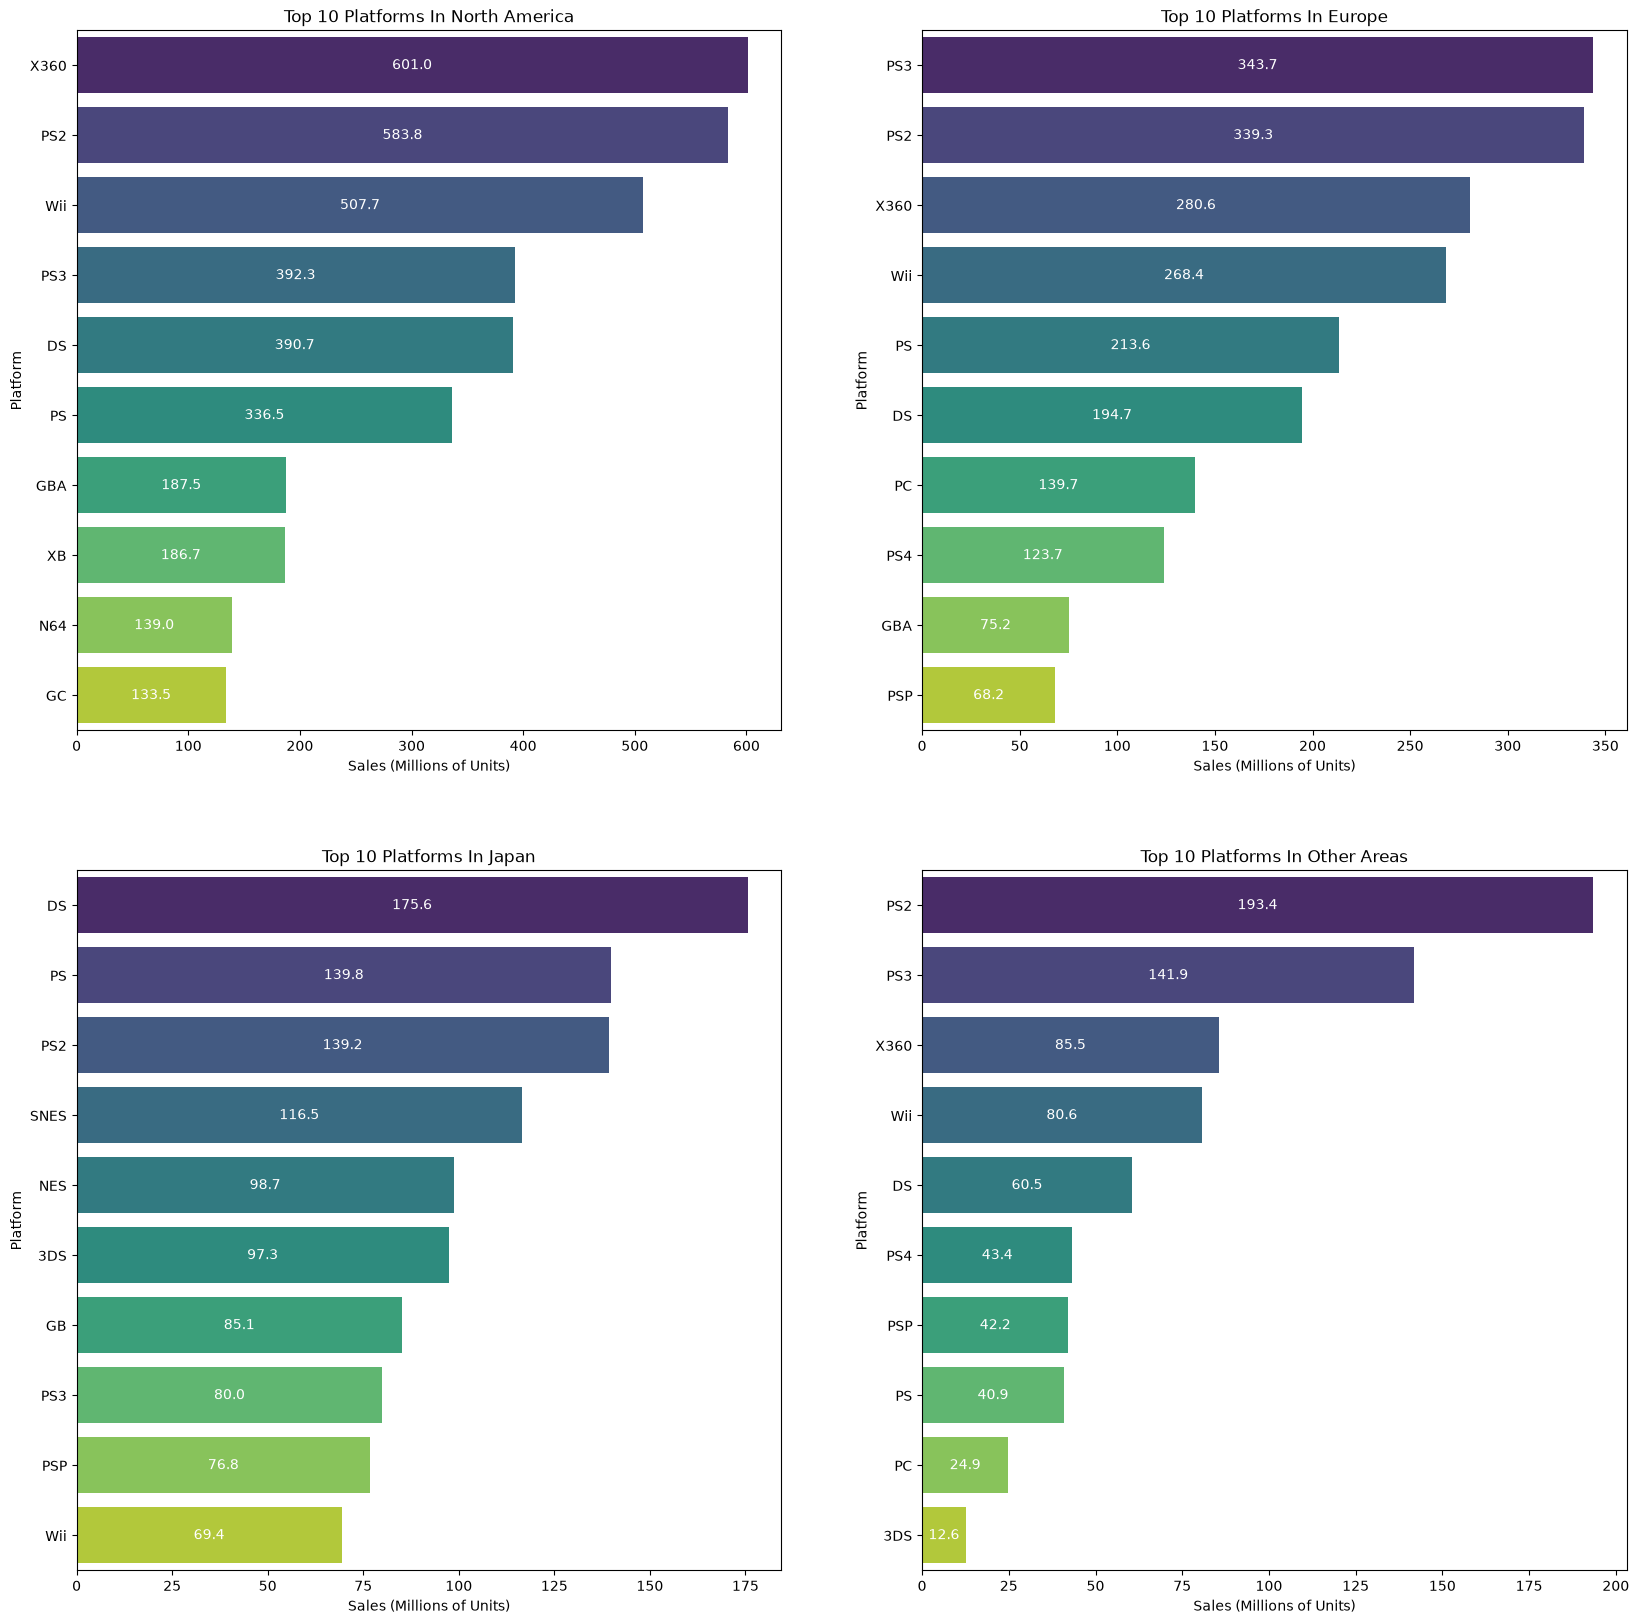

In [16]:
na2 = df.groupby("Platform")["NA_Sales"].sum().sort_values(ascending=False).reset_index()[:10]
eu2 = df.groupby("Platform")["EU_Sales"].sum().sort_values(ascending=False).reset_index()[:10]
jp2 = df.groupby("Platform")["JP_Sales"].sum().sort_values(ascending=False).reset_index()[:10]
other2 = df.groupby("Platform")["Other_Sales"].sum().sort_values(ascending=False).reset_index()[:10]




fig, ax = plt.subplots(figsize=(20,20), nrows=2, ncols=2)
sns.barplot(data=na2, x="NA_Sales", y="Platform", palette="viridis", hue="Platform", ax=ax[0,0])
ax[0,0].set_title("Top 10 Platforms In North America")
ax[0,0].set_xlabel("Sales (Millions of Units)")
ax[0,0].set_ylabel("Platform")
for container in ax[0,0].containers:
    ax[0,0].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=eu2, x="EU_Sales", y="Platform", palette="viridis", hue="Platform", ax=ax[0,1])
ax[0,1].set_title("Top 10 Platforms In Europe")
ax[0,1].set_xlabel("Sales (Millions of Units)")
ax[0,1].set_ylabel("Platform")
for container in ax[0,1].containers:
    ax[0,1].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=jp2, x="JP_Sales", y="Platform", palette="viridis", hue="Platform", ax=ax[1,0])
ax[1,0].set_title("Top 10 Platforms In Japan")
ax[1,0].set_xlabel("Sales (Millions of Units)")
ax[1,0].set_ylabel("Platform")
for container in ax[1,0].containers:
    ax[1,0].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=other2, x="Other_Sales", y="Platform", palette="viridis", hue="Platform", ax=ax[1,1])
ax[1,1].set_title("Top 10 Platforms In Other Areas")
ax[1,1].set_xlabel("Sales (Millions of Units)")
ax[1,1].set_ylabel("Platform")
for container in ax[1,1].containers:
    ax[1,1].bar_label(container, fmt="%.1f", label_type="center", color="white")

### Observation
Platform preference breaks sharply by region here. In North America, Xbox 360 (Microsoft, 
an American company) is the top platform, edging out the global #1 platform, PS2, into 
second place — interestingly mirroring, on a smaller scale, the same domestic-preference 
pattern seen later in Japan.

Europe and the "Other" regions follow a very similar pattern to each other: PlayStation 3 
and PS2 take the top two spots (in reverse order between the two regions), followed by 
Xbox 360 in third. Notably, neither region has a single Nintendo platform in their top 3 — 
Wii shows up 4th in both — suggesting these markets lean strongly toward Sony hardware, 
with Xbox as a solid second choice and Nintendo trailing behind.

Japan shows the most extreme regional pattern of all: every platform in its top 10 belongs 
to either Sony or Nintendo — both Japanese companies. This is the same "domestic dominance" 
pattern already seen in the Publisher section, now showing up at the hardware level as well.

## Games

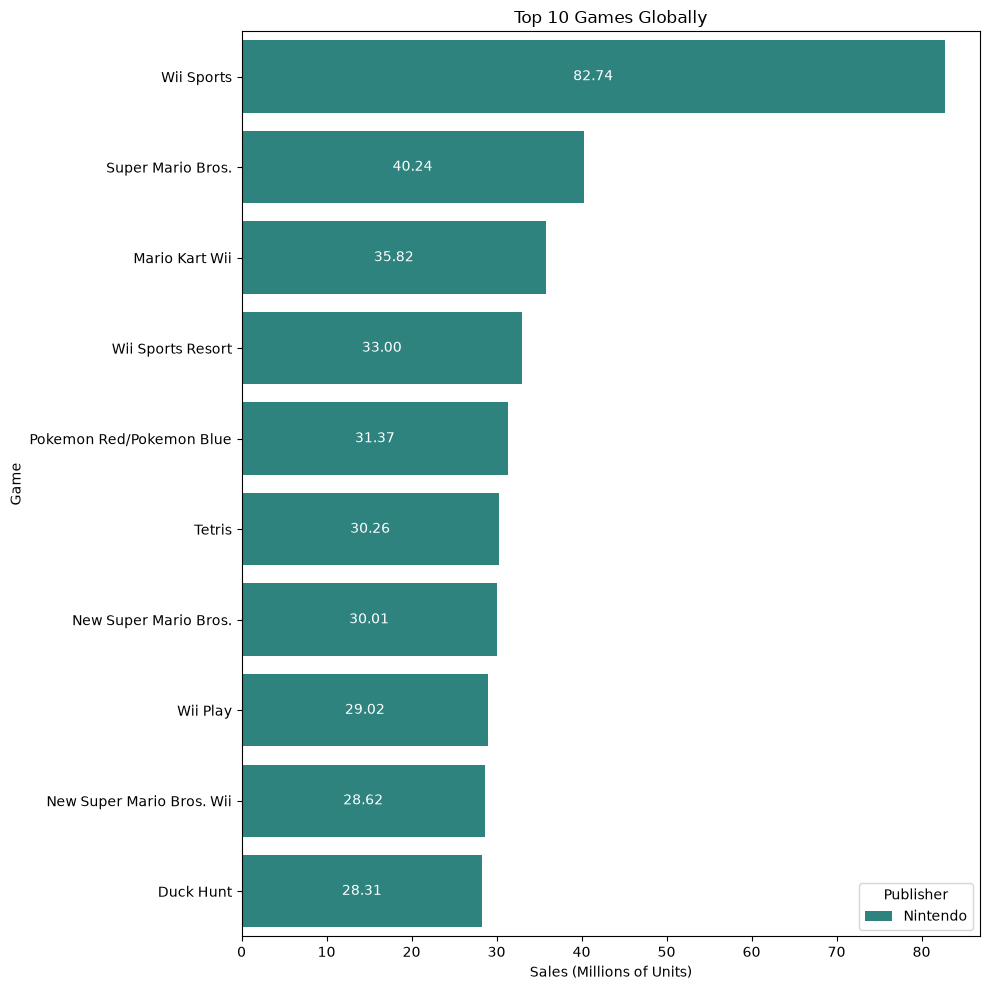

In [17]:
global_games = df.sort_values(by="Global_Sales", ascending=False)[:10]

fig, ax = plt.subplots(figsize=(10,10))
sns.barplot(data=global_games, x="Global_Sales", y="Name",palette="viridis", hue="Publisher", ax=ax)
ax.set_title("Top 10 Games Globally")
ax.set_xlabel("Sales (Millions of Units)")
ax.set_ylabel("Game")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center", color="white")

plt.tight_layout()
plt.show()

### Observation
Consistent with the Publisher section, all of the top 10 best-selling games globally 
belong to Nintendo. The list is dominated by early, foundational titles — Super Mario 
Bros., Pokémon Red/Blue, Wii Sports, and Tetris (published by Nintendo for Game Boy) — 
suggesting Nintendo's dominance in the Publisher rankings isn't just broad market share, 
but is heavily concentrated in a handful of iconic, best-selling franchises.

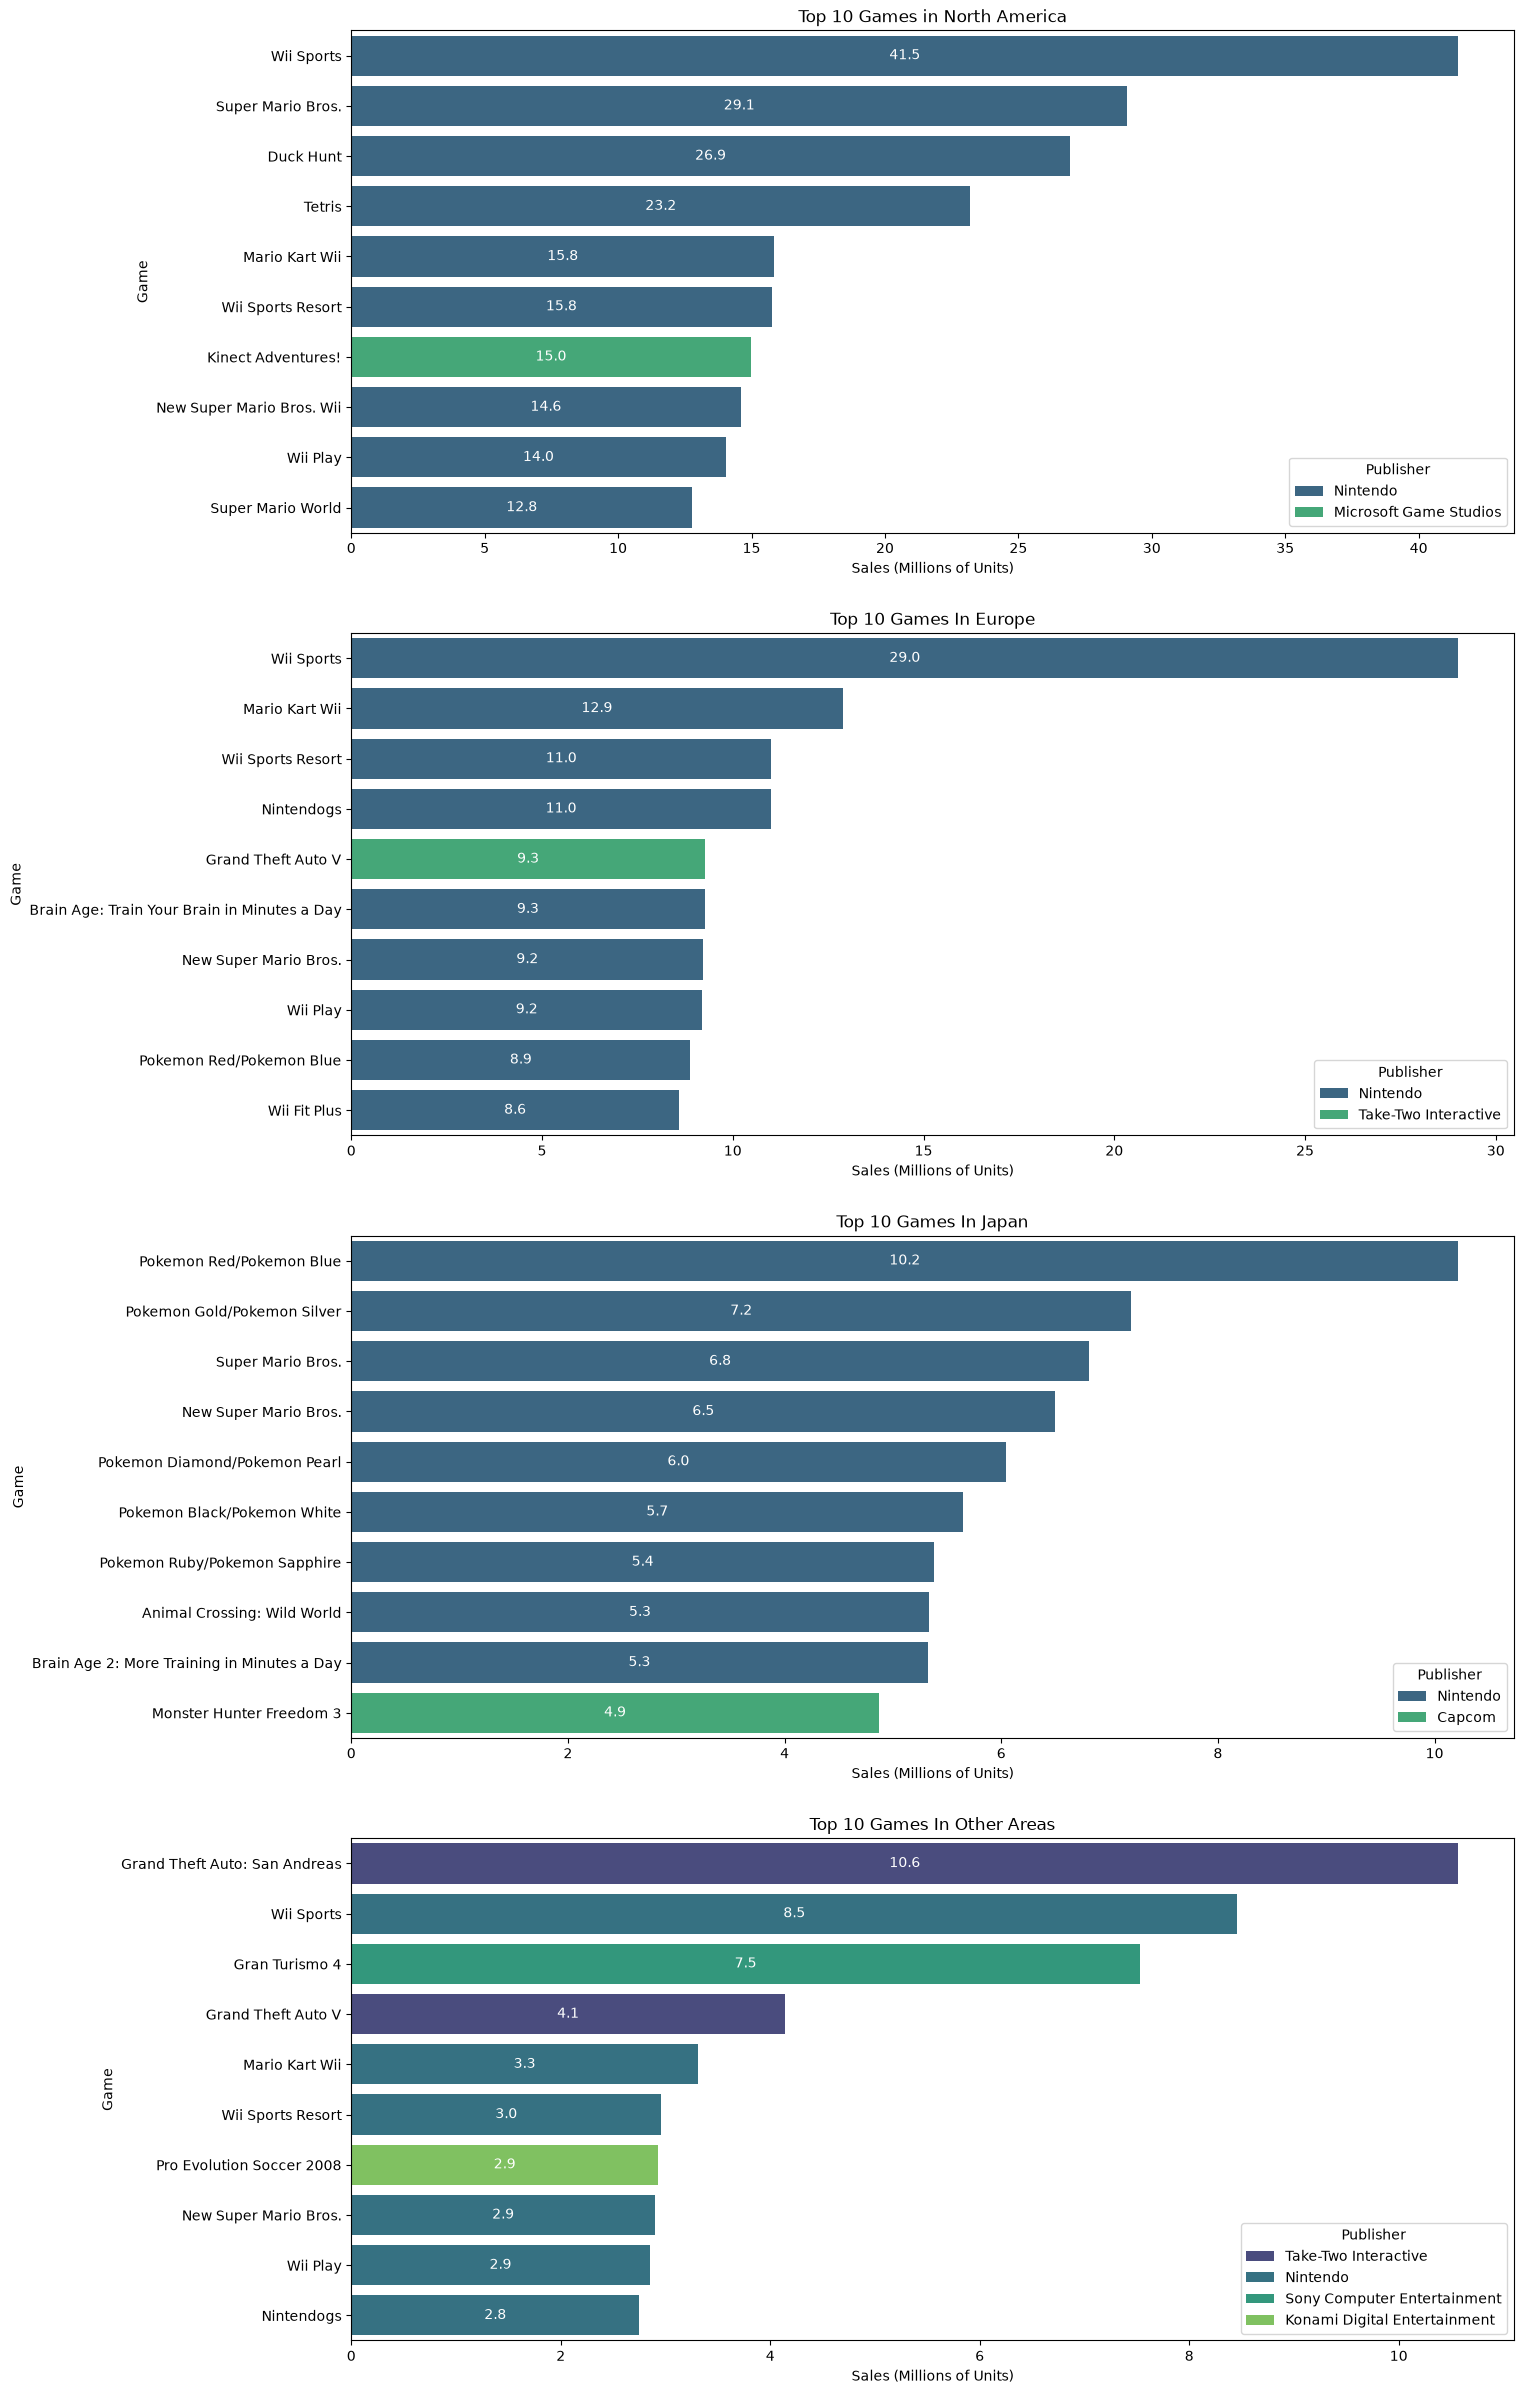

In [18]:
na3 = df.sort_values(by="NA_Sales", ascending=False)[:10]
eu3 = df.sort_values(by="EU_Sales", ascending=False)[:10]
jp3 = df.sort_values(by="JP_Sales", ascending=False)[:10]
other3 = df.sort_values(by="Other_Sales", ascending=False)[:10]

fig, ax = plt.subplots(figsize=(15,30), nrows=4, ncols=1)
sns.barplot(data=na3, x="NA_Sales", y="Name", palette="viridis", hue="Publisher", ax=ax[0])
ax[0].set_title("Top 10 Games in North America")
ax[0].set_xlabel("Sales (Millions of Units)")
ax[0].set_ylabel("Game")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=eu3, x="EU_Sales", y="Name", palette="viridis", hue="Publisher", ax=ax[1])
ax[1].set_title("Top 10 Games In Europe")
ax[1].set_xlabel("Sales (Millions of Units)")
ax[1].set_ylabel("Game")
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=jp3, x="JP_Sales", y="Name", palette="viridis", hue="Publisher", ax=ax[2])
ax[2].set_title("Top 10 Games In Japan")
ax[2].set_xlabel("Sales (Millions of Units)")
ax[2].set_ylabel("Game")
for container in ax[2].containers:
    ax[2].bar_label(container, fmt="%.1f", label_type="center", color="white")

sns.barplot(data=other3, x="Other_Sales", y="Name", palette="viridis", hue="Publisher", ax=ax[3])
ax[3].set_title("Top 10 Games In Other Areas")
ax[3].set_xlabel("Sales (Millions of Units)")
ax[3].set_ylabel("Game")
for container in ax[3].containers:
    ax[3].bar_label(container, fmt="%.1f", label_type="center", color="white")

### Observation
North America's top 10 is almost entirely Nintendo, echoing the global chart. Wii Sports, 
Duck Hunt, and Tetris sitting at the top points to hardware bundling driving a lot of this 
volume, rather than pure standalone purchases. There's also a clear lean toward local 
multiplayer and family-friendly titles — Mario Kart Wii, New Super Mario Bros. Wii, and Wii 
Play are all pick-up-and-play, couch co-op games rather than solo or narrative-driven 
experiences. Kinect Adventures! being the only non-Nintendo title here shows the same 
motion-control wave (Wii Sports Resort, Kinect Adventures!) was strong across both Nintendo 
and Microsoft hardware in this region.

Europe looks similar to North America overall, but with a few differences worth noting. 
Nintendogs and Brain Age both charting shows strong DS adoption among casual, non-traditional 
gamers, and Wii Fit Plus alongside Wii Sports Resort and Wii Play shows real appetite for 
fitness/lifestyle motion games. The standout difference, though, is Grand Theft Auto V 
breaking into the top 10 — the only mature, open-world title to do so in any region's top 
10 — suggesting Europe has a stronger appetite for this kind of game than NA or Japan.

Japan's top 10 confirms everything from earlier — every game is from a Japanese publisher, 
and Pokémon alone takes 5 of the 10 spots, showing an exceptionally strong preference for 
collecting/RPG mechanics across generations. Unlike NA/EU, this list is almost entirely 
handheld titles, reinforcing Japan's portable-gaming culture. Monster Hunter Freedom 3 
also stands out as the region's clearest example of local co-op/group-play culture, while 
Animal Crossing and Brain Age 2 reflect an audience drawn to relaxed, daily-life simulation 
software rather than traditional action/adventure games.

"Other" regions tell a very different story. Grand Theft Auto: San Andreas and Gran Turismo 
4 leading the list points to long-term PlayStation hardware dominance in these markets. Pro 
Evolution Soccer 2008 charting here — and nowhere else — supports the soccer/football 
hypothesis from the Publisher section, even though it's Konami's title rather than EA's. 
Both GTA titles charting highly also shows a much stronger appetite for mature, open-world 
action here than in NA or Japan, while Wii Sports and Mario Kart Wii still show up, proving 
family-friendly motion gaming had genuine global reach even in a PlayStation-dominant region.

## Region

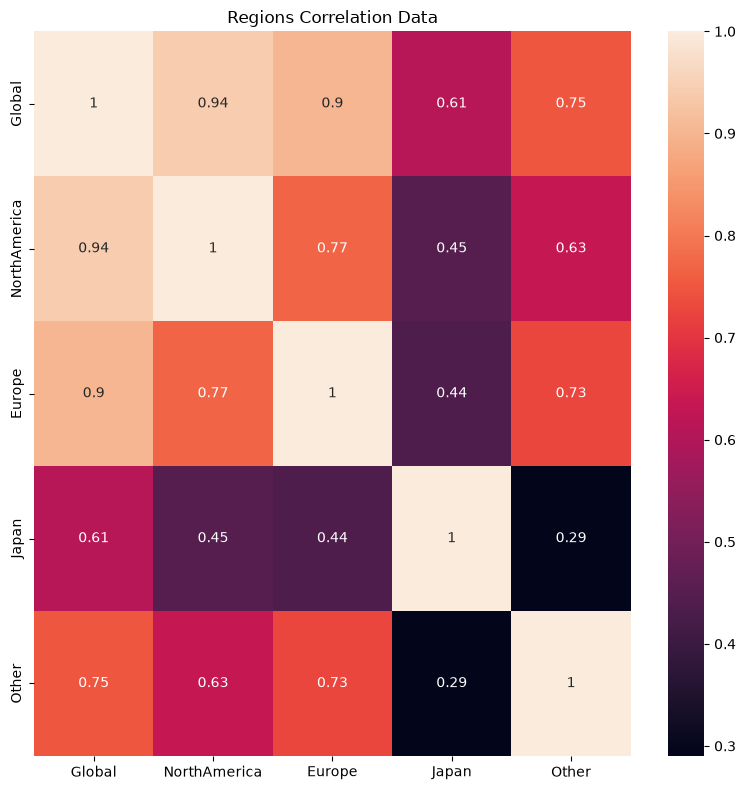

In [19]:
region_corr = df[["Global_Sales","NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].corr()
fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data=region_corr, annot=True, ax=ax)
ax.set_xticklabels("Global NorthAmerica Europe Japan Other".split())
ax.set_yticklabels("Global NorthAmerica Europe Japan Other".split())
ax.set_title("Regions Correlation Data")

plt.tight_layout()
plt.show()

### Observation
North America and Europe, which together make up roughly 75% of the global market, show the 
highest correlation with the Global figures (0.94 and 0.90 respectively) — unsurprising given 
their combined weight in the total. They're also highly correlated with each other (0.77), 
confirming the similar taste we found earlier in the Publisher, Genre, and Platform sections. 
"Other" regions correlate moderately with both NA and Europe (0.63 and 0.73), suggesting some 
shared taste but with more variation.

Japan stands apart from every other region. Its correlation with Global sales is only 0.61 
(the weakest of any region), and its correlation with NA (0.45), Europe (0.44), and 
especially "Other" (0.29) is notably low. This quantitatively confirms what we found 
throughout the rest of this analysis — Japan's taste in publishers, genres, and platforms 
consistently diverges from the rest of the world, making it the most distinct and 
independent market in the dataset.

## Key Findings

This dataset is heavily shaped by early, pioneering titles — the games that were first to 
define the industry, back when everyone simply wanted to experience "gaming" for the first 
time. Since Nintendo was one of the earliest major players, it set sales records that 
haven't been broken since. This doesn't mean these franchises aren't popular anymore, but 
it does mean they carry disproportionate weight in the overall charts. The industry is also 
highly concentrated overall — just three publishers (Nintendo, EA, and Activision) account 
for nearly 58% of total global sales, and a handful of individual titles dominate the top 
of the charts in every region. Still, by looking past these industry-defining titles, we 
can understand each region's actual preferences based on the data.

#### North America
North America makes up nearly half of the global market, giving it significant influence 
over overall industry trends and, likely, other regions' perceptions of what's popular. The 
region shows fair loyalty to its own domestic publishers, while also maintaining strong 
interest in Nintendo. Action is the clear favorite genre, followed by Sports and Shooter. 
On the hardware side, Xbox (a domestic platform) is the top choice, followed by Sony and 
Nintendo. Gameplay-wise, North America leans toward local multiplayer and family-friendly 
titles first, with pick-up-and-play games as a secondary preference. Overall, North America 
shares the most similar taste with the European market.

#### Europe
Europe makes up roughly 27% of the global market and shares the most similar taste with 
North America of any region, with a correlation of 0.77 between the two. Genre preference 
mirrors North America closely, with Action leading, followed by Sports and Shooter. On the 
hardware side, however, Europe leans differently — PlayStation 3 is the top platform, 
followed by PS2 and Xbox 360, with no Nintendo platform appearing in the top 3, suggesting a 
stronger overall preference for Sony hardware than North America shows. Handheld and 
lifestyle software also performs unusually well here, with Nintendogs and Brain Age pointing 
to strong DS adoption among casual, non-traditional gamers, and Wii Fit Plus showing real 
appetite for fitness-focused motion games. Europe is also the only region where a mature, 
open-world title (Grand Theft Auto V) breaks into the top 10 best-selling games, suggesting 
a stronger appetite for this genre than either North America or Japan.

#### Japan
Japan stands apart from every other region in this dataset, both in taste and in behavior. 
Its correlation with the Global market (0.61) is the weakest of any region, and its 
correlation with North America (0.45), Europe (0.44), and especially "Other" (0.29) is 
notably low. Unlike every other region, Japan shows almost no interest in foreign publishers 
or platforms — its top publishers (Nintendo, Namco Bandai, Konami, Sony, Capcom) and top 
platforms (DS, PS, PS2, SNES, NES) are entirely Japanese-owned. Role-Playing is by far 
Japan's favorite genre, well above the global average, and Pokémon alone accounts for 5 of 
Japan's top 10 best-selling games. Gameplay-wise, Japan leans toward handheld, portable 
experiences over home console blockbusters, with titles like Animal Crossing and Brain Age 2 
reflecting a market drawn to relaxed, daily-life simulation software, while Monster Hunter 
Freedom 3 highlights a strong local co-op, group-play culture.

#### Other
The "Other" regions (Latin America, Australia, and the remaining global markets) diverge 
from both the NA/EU and Japan patterns. Unlike every other region, EA — not Nintendo — is 
the top publisher here, and the appearance of Pro Evolution Soccer 2008 in the regional top 
10 (the only region where a soccer title charts) supports the idea that football/soccer 
games perform unusually well in these markets. Hardware preference leans heavily toward 
Sony, with PlayStation 2 and PlayStation 3 as the top two platforms, and Grand Theft Auto: 
San Andreas and Gran Turismo 4 leading the regional top 10 — pointing to a much stronger 
appetite for mature, open-world action here than in North America or Japan. Correlation 
with NA (0.63) and Europe (0.73) suggests some shared taste with the West, while the near-
zero correlation with Japan (0.29) confirms this region's taste has little in common with 
Japan's domestic-driven market.

#### Overall
Across all four regions, the data points to two consistent patterns: first, the industry is 
highly concentrated, with a small number of publishers, platforms, and individual titles 
accounting for a disproportionate share of total sales. Second, regional taste is real and 
measurable — North America and Europe behave almost like a single combined market, while 
Japan operates almost entirely independently, favoring domestic publishers, handheld 
hardware, and Role-Playing games well above the global norm. Interestingly, Sony's success 
is concentrated in hardware rather than publishing, while Nintendo dominates both — a 
distinction that only becomes visible once publisher and platform data are compared side 
by side.
